# Claim Severity Prediction (Risk Model)

### Import Required Libraries

In [1]:
import sys 
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_3/insurance-risk-analytics/src'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_3/insurance-risk-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_3\insurance-risk-analytics


In [2]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from data_loader import load_data
from data_preprocessor import num_impute, cat_impute, scaler
from train_test_split import train_test_split
import model_regressor as m

### load the dataset

In [3]:
df = load_data('../data/processed/cleaned_insurance_data.csv')

df.head()

C:\Users\dagic\OneDrive\Documents\KAIM\Week_3\insurance-risk-analytics\src\data_loader.py:15: DtypeWarning: Columns (0: MaritalStatus, 1: Gender, 2: CapitalOutstanding, 3: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, **kwargs)


Dataset loaded successfully.
Shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


## Data preparation

### Handling Missing Values by Imputation

In [4]:
if 'CapitalOutstanding' in df.columns:
    df['CapitalOutstanding'] = pd.to_numeric(df['CapitalOutstanding'], errors='coerce')

# 3. Handle the very last NaN column (NumberOfVehiclesInFleet)
# Missing fleet count usually means 0 (not part of a fleet)
if 'NumberOfVehiclesInFleet' in df.columns:
    df['NumberOfVehiclesInFleet'] = df['NumberOfVehiclesInFleet'].fillna(0)

In [5]:
numerical_cols = ['PolicyID','mmcode', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate', 'CapitalOutstanding',
                   'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']

for col in numerical_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')

print(df[numerical_cols].dtypes)

PolicyID                      int64
mmcode                      float64
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
NumberOfDoors               float64
CustomValueEstimate         float64
CapitalOutstanding          float64
SumInsured                  float64
CalculatedPremiumPerTerm    float64
TotalPremium                float64
TotalClaims                 float64
dtype: object


In [6]:
df = num_impute(df, numerical_cols)

In [7]:
print(df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


In [8]:
categorical_cols = ['Gender','Province','VehicleType','CoverType','make','MaritalStatus', 'Bank', 'AccountType', 'Model', 'bodytype']

df = cat_impute(df, categorical_cols)
print(df[categorical_cols].dtypes)

Gender           str
Province         str
VehicleType      str
CoverType        str
make             str
MaritalStatus    str
Bank             str
AccountType      str
Model            str
bodytype         str
dtype: object


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [10]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [12]:
zero_fill_cols = ['NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']
existing_cols = [col for col in zero_fill_cols if col in df.columns]
if existing_cols:
    df[existing_cols] = df[existing_cols].fillna(0)

In [13]:
print(df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


## Feature Engineering

In [14]:
df['VehicleAge'] = (2025 - df['RegistrationYear'])
if 'VehicleIntroDate' in df.columns:
    df = df.drop(columns=['VehicleIntroDate'])

In [15]:
all_categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

C:\Users\dagic\AppData\Local\Temp\ipykernel_8808\2309419677.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [16]:
df['Margin'] = (df['TotalPremium'] -df['TotalClaims'])

In [17]:
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

In [18]:
severity_df = df[df['TotalClaims'] > 0]
severity_df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,VehicleAge,Margin,HasClaim
203,46222,4044.0,2014-10-01,False,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,2294.096491,14,-2294.096491,1
284,82062,7174.0,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,2040.473684,19,-2018.543860,1
1560,119591,8672.0,2015-04-01,False,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,1213.889211,46492.211754,11,-45278.322544,1
1779,50193,283.0,2014-10-01,False,,Close Corporation,Mr,English,Standard Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,645.017456,26516.859649,16,-25871.842193,1
1943,119582,8672.0,2015-04-01,False,,Close Corporation,Mr,English,First National Bank,Current account,...,Income Protector,Optional Extended Covers,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,74.561404,6140.350877,11,-6065.789474,1


### One-hot Encoding 

In [19]:
severity_df = pd.get_dummies(severity_df,columns=all_categorical_cols,drop_first=True)

### Scaling the variables

In [20]:
columns_scaler = ['TotalClaims']
df_scaled = scaler('minMaxScaler', severity_df, columns_scaler)
df_scaled

,UnderwrittenCoverID,PolicyID,IsVATRegistered,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,...,CoverType_Third Party,CoverType_Windscreen,CoverGroup_Credit Protection,CoverGroup_Deposit Cover,CoverGroup_Income Protector,CoverGroup_Motor Comprehensive,Section_Motor Comprehensive,Section_Optional Extended Covers,Product_Mobility Commercial Cover: Monthly,Product_Mobility Metered Taxis: Monthly
203,46222,4044.0,False,1982,4042080.0,2011,4.0,1781.0,118.0,4.0,...,False,False,False,False,False,False,True,False,False,True
284,82062,7174.0,True,1625,22089200.0,2006,6.0,3984.0,182.0,5.0,...,False,True,False,False,False,False,True,False,False,True
1560,119591,8672.0,False,2066,5037006.0,2014,4.0,1598.0,100.0,4.0,...,False,False,False,False,False,False,True,False,False,True
1779,50193,283.0,False,4093,64082300.0,2009,5.0,2459.0,80.0,2.0,...,False,False,False,False,False,False,True,False,True,False
1943,119582,8672.0,False,2066,5037006.0,2014,4.0,1598.0,100.0,4.0,...,False,False,False,False,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998512,263942,962.0,False,7941,40312150.0,2005,4.0,4300.0,107.0,2.0,...,False,True,False,False,False,False,True,False,True,False
998848,937,138.0,False,2196,22840150.0,2013,4.0,2237.0,76.0,4.0,...,False,False,False,False,False,False,True,False,True,False
999218,3255,394.0,False,2196,22850150.0,2014,4.0,2438.0,102.0,4.0,...,False,False,False,False,False,False,True,False,True,False
999701,238713,20611.0,False,2196,22840150.0,2014,4.0,2237.0,76.0,4.0,...,False,False,False,False,False,True,True,False,False,False


## Train-Test Split

In [21]:
# Create a explicit list of columns that look at the financial outcomes
leaky_financial_cols = ['CalculatedPremiumPerTerm', 'TotalPremium', 'HasClaim'] 
high_cardinality_cols = ['Model', 'bodytype', 'VehicleIntroDate']
# Drop them along with your target variable
X = severity_df.drop(columns=['TotalClaims'] + leaky_financial_cols + high_cardinality_cols, errors='ignore')
y = severity_df['TotalClaims']

y = severity_df['TotalClaims']

X_train, X_test, y_train, y_test = m.split_data(X, y)

In [22]:
severity_df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'IsVATRegistered', 'PostalCode',
       'mmcode', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts',
       'NumberOfDoors',
       ...
       'CoverType_Third Party', 'CoverType_Windscreen',
       'CoverGroup_Credit Protection', 'CoverGroup_Deposit Cover',
       'CoverGroup_Income Protector', 'CoverGroup_Motor Comprehensive',
       'Section_Motor Comprehensive', 'Section_Optional Extended Covers',
       'Product_Mobility Commercial Cover: Monthly',
       'Product_Mobility Metered Taxis: Monthly'],
      dtype='str', length=350)

In [23]:
# Drop the date column for now if you aren't engineering features from it
if 'VehicleIntroDate' in X_train.columns:
    X_train = X_train.drop(columns=['VehicleIntroDate'])
    X_test = X_test.drop(columns=['VehicleIntroDate'])

# Catch remaining object/categorical columns with the mode
for col in X_train.select_dtypes(include=['object']).columns:
    mode_value = X_train[col].mode()[0] if not X_train[col].mode().empty else 'Unknown'
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

#Final sanity check safety net (for any remaining numeric columns)
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

# Verify it's perfectly clean
print("Remaining NaNs:", X_train.isna().sum().sum())

Remaining NaNs: 0


## Claim Severity Prediction Models

    -   Goal: Predict TotalClaims for policies that filed claims.

## Model Training

In [35]:
# Check for NaNs in your training features
print("--- Missing values in X_train ---")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\n--- Missing values in y_train ---")
print(y_train.isna().sum())

--- Missing values in X_train ---
Series([], dtype: int64)

--- Missing values in y_train ---
0


In [36]:
X_train.columns[X_train.columns.duplicated()]

Index([], dtype='str')

In [37]:
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [38]:
X_train.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [39]:
X_train.select_dtypes(include=['datetime']).columns

Index([], dtype='str')

In [40]:
# List of raw text columns to drop before training
cols_to_drop = ['VehicleIntroDate']

for col in cols_to_drop:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])


In [41]:
lr_model, rfr_model, xgb_model = m.train_models(X_train, y_train)

## Model Evaluation

In [42]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
mae_scores, mse_scores, r2_scores = [], [], []

for model in [lr_model, rfr_model, xgb_model]:
    mae, mse, r2, _ = m.evaluate_model(model, X_test, y_test)
    mae_scores.append(mae)
    mse_scores.append(mse)
    r2_scores.append(r2)

In [43]:
# Prints the performance of each model so we can compare them.
for i, model_name in enumerate(models):
    print(f"Evaluation results for {model_name}:")
    print(f" - Mean Absolute Error (MAE): {mae_scores[i]}")
    print(f" - Mean Squared Error (MSE): {mse_scores[i]}")
    print(f" - R-squared (R2) Score: {r2_scores[i]}")
    print("\n")


Evaluation results for Linear Regression:
 - Mean Absolute Error (MAE): 156.4511793163273
 - Mean Squared Error (MSE): 57209.05047811949
 - R-squared (R2) Score: 0.9999644277183232


Evaluation results for Random Forest:
 - Mean Absolute Error (MAE): 436.9633155913966
 - Mean Squared Error (MSE): 11703265.85920757
 - R-squared (R2) Score: 0.9927229718689138


Evaluation results for XGBoost:
 - Mean Absolute Error (MAE): 924.6708486888401
 - Mean Squared Error (MSE): 26426881.791286744
 - R-squared (R2) Score: 0.9835679062130522




## Comparing Model Performance

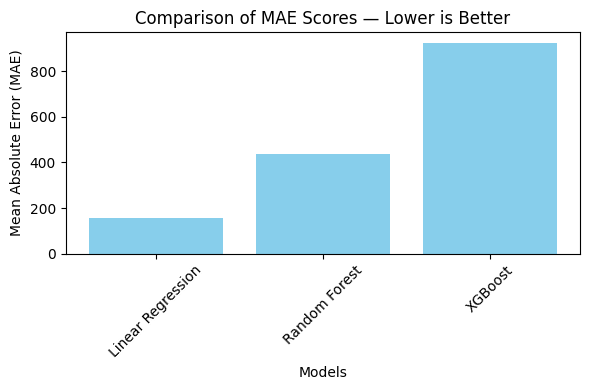

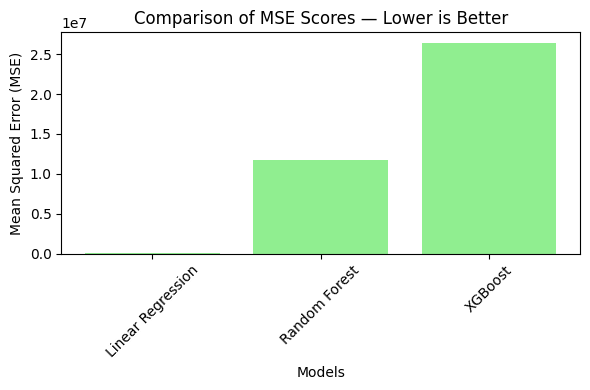

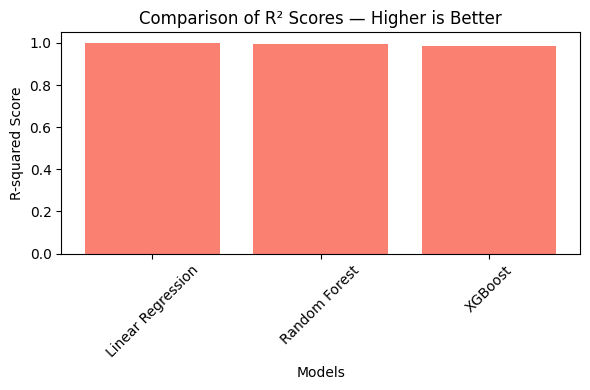

In [44]:
m.plot_metrics(models, mae_scores, mse_scores, r2_scores)

In [45]:
import pandas as pd
import numpy as np

# Get the coefficients (weights) assigned by the Linear Regression model
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': lr_model.coef_
})

# Look for the absolute largest weights driving the predictions
coefficients['Absolute_Weight'] = coefficients['Weight'].abs()
top_leakers = coefficients.sort_values(by='Absolute_Weight', ascending=False).head(10)

print("--- Top 10 Features Driving the Perfect Linear Fit ---")
print(top_leakers[['Feature', 'Weight']])

--- Top 10 Features Driving the Perfect Linear Fit ---
                                         Feature      Weight
209  Model_CRAFTER 50 2.0 BiTDi HR 120KW F/C P/V  945.101345
336                        CoverType_Third Party -851.596755
325                    CoverCategory_Third Party -851.596755
187                  Model_C200 CDi CLASSIC  A/T -793.487700
243                       Model_MICROBUS 2.3 P/S -789.026016
202                        Model_COROLLA 130 GLE -784.282861
260                  Model_SESBUYILE 2.7 16 SEAT  706.143725
264               Model_SPRINTER 309 CDI F/C P/V -628.466349
236                Model_JETTA 4 1.6 COMFORTLINE -606.923292
153                             Model_316i (F30) -562.281163
